# [LAB 06] 데이터 시각화 - 2-2 Line Plot 옵션 설정 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import my_plot
import seaborn as sb

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기 

In [2]:
origin = load_data('icecream_sales')
origin

📚 '달콤 스쿱' 아이스크림 가게의 매출 데이터 (인덱스 없음)


,Date,Flavor,Topping,Price,Quantity
0,2023-07-01,초콜릿,아몬드,3500,20.000
1,2023-07-01,바닐라,초코시럽,3000,25.000
2,2023-07-01,딸기,연유,3200,18.000
3,2023-07-02,민트초코,초코칩,3800,15.000
4,2023-07-02,초콜릿,아몬드,3500,22.000
5,2023-07-02,바닐라,NaN,3000,30.000
6,2023-07-03,딸기,연유,3200,25.000
7,2023-07-03,민트초코,초코칩,3800,NaN
8,2023-07-03,바닐라,초코시럽,3000,28.000
9,2023-07-04,초콜릿,아몬드,3500,18.000


## #02. 선 모양 설정하기 

### 1. 선 색상/ 선 스타일, 굵기 / 마커 모양, 크기, 테두리 색상, 면색상, 테두리 굵기 

findfont: Failed to find font weight 500, now using 400.


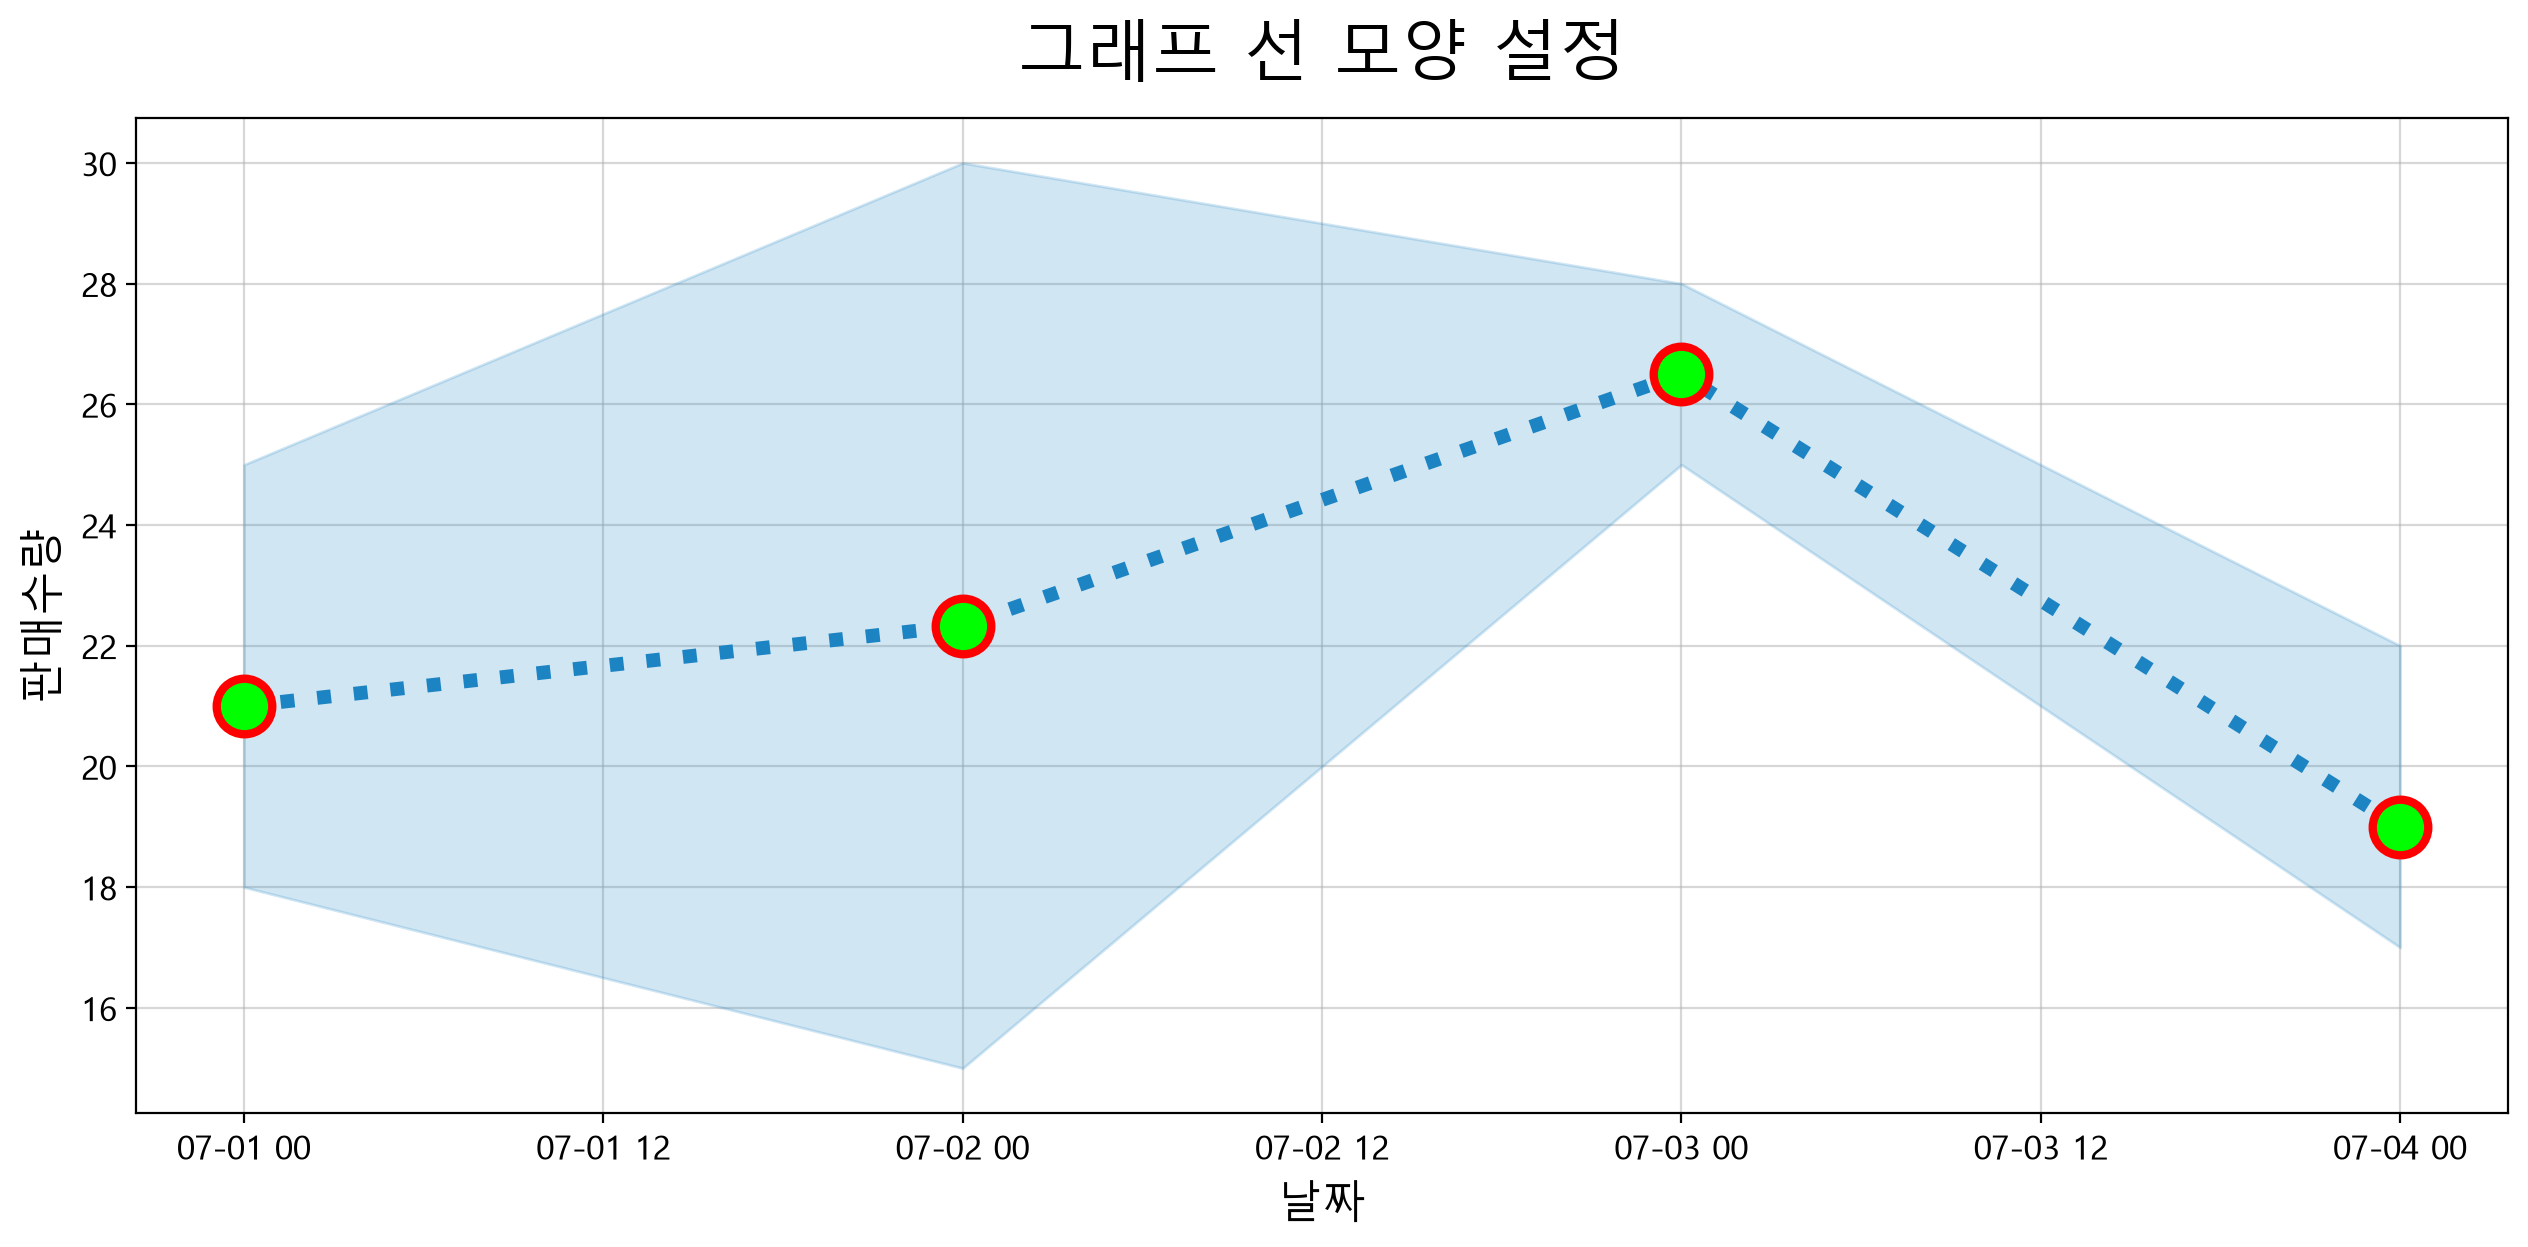

In [3]:
# 그래프 초기화 
fig, ax = my_plot.init(title="그래프 선 모양 설정", xlabel="날짜", ylabel="판매수량")

# 그래프 그리기 
sb.lineplot(data=origin, x='Date', y='Quantity', c="#1D84C3", 
            linestyle=':', linewidth=5, marker="o", markersize=20,
            markeredgewidth=3, markerfacecolor="#00ff00", markeredgecolor="#ff0000")

# 출력 
my_plot.show()

## #03. 축 설정

### 1. 축 범위 / 표시할 값 설정하기 [1/2]

(18.0, 28.0)

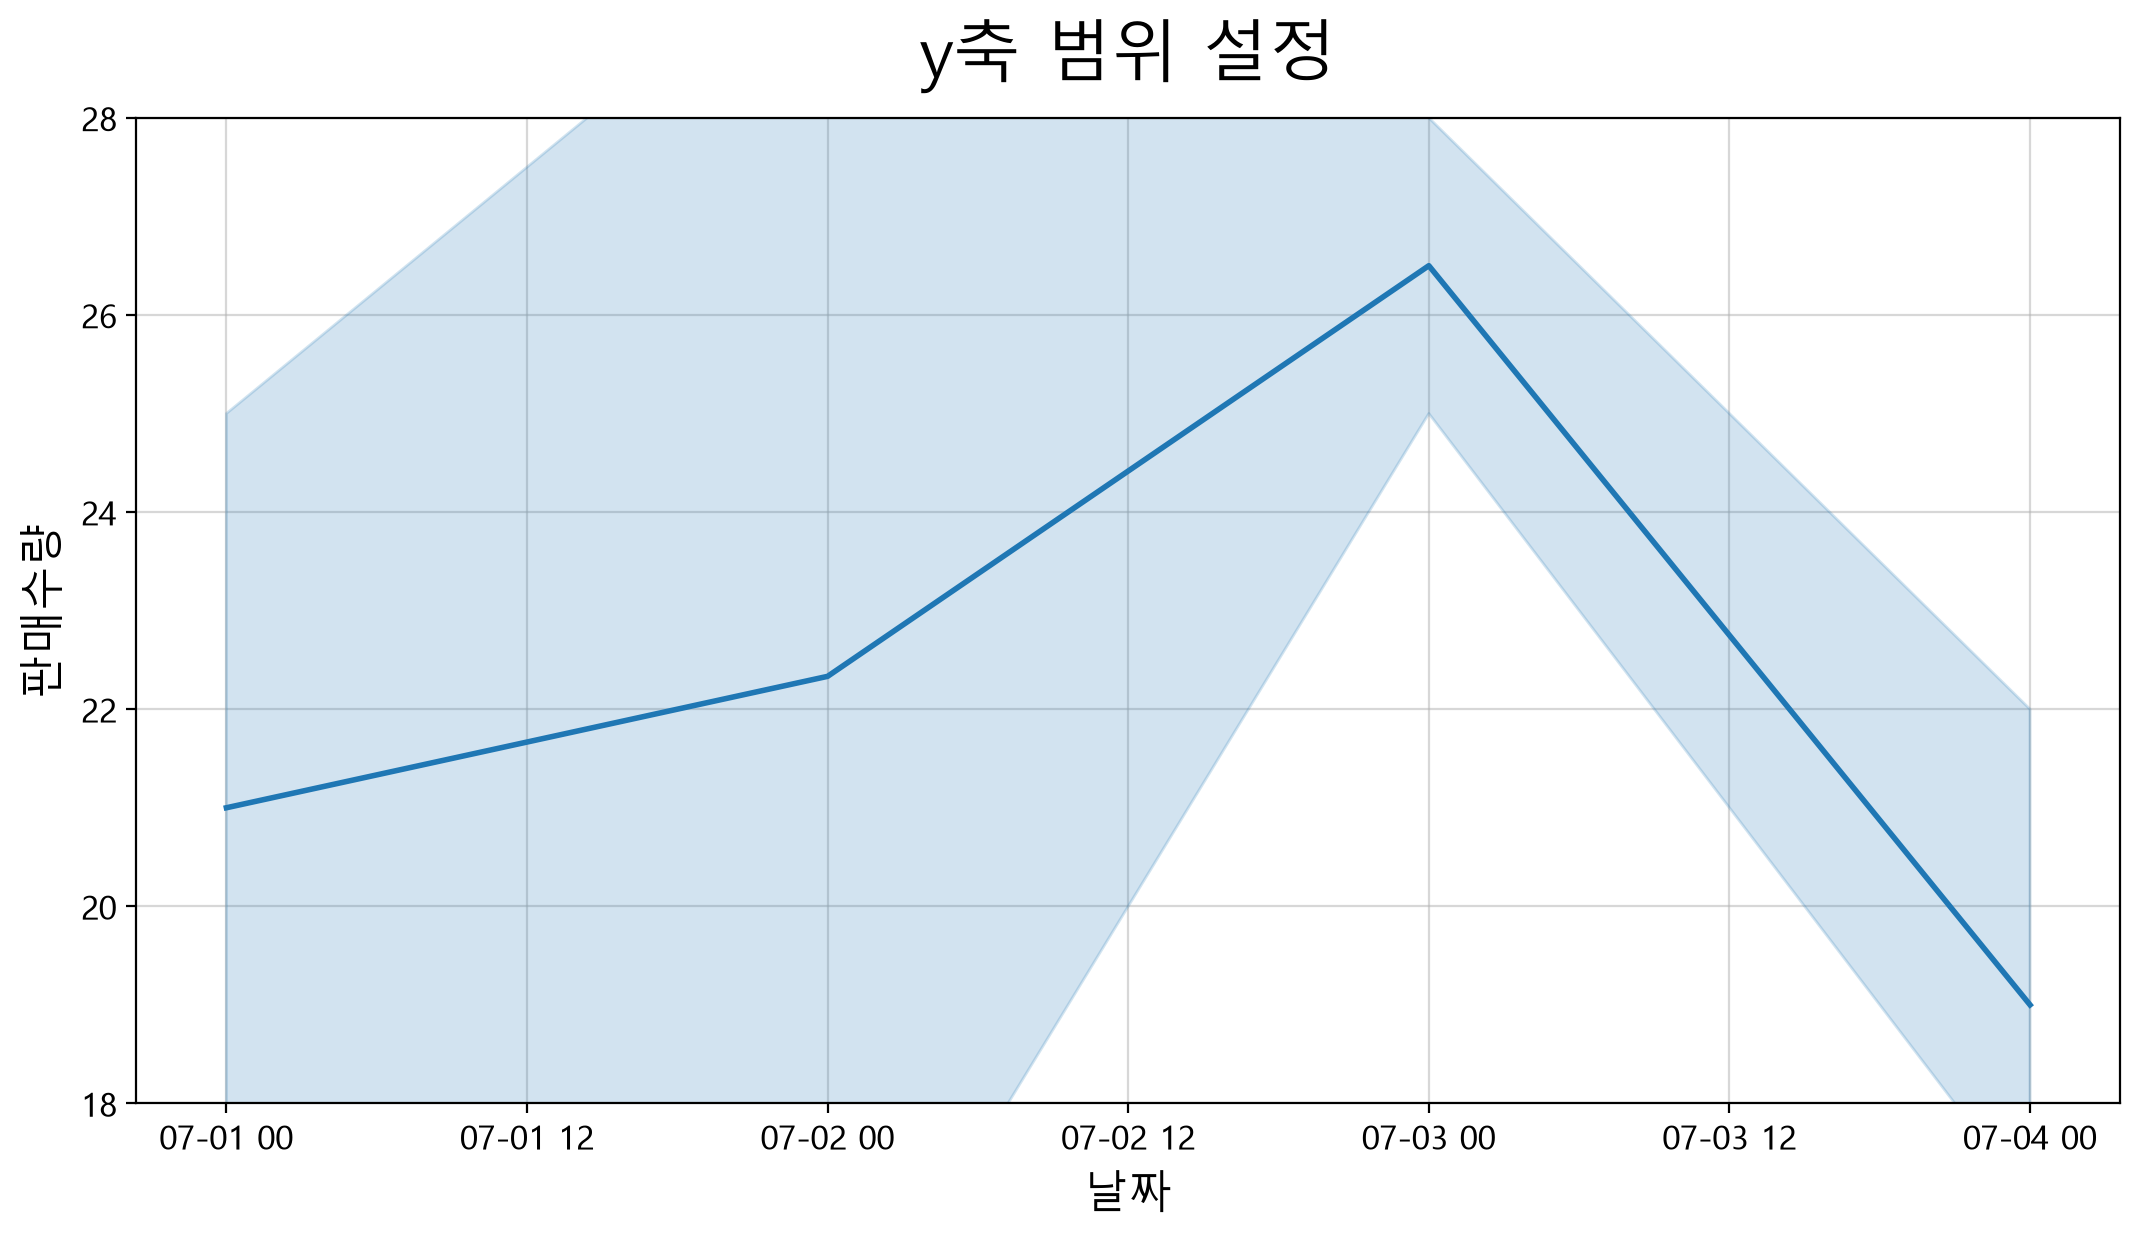

In [4]:
# 그래프 초기화 
fig, ax = my_plot.init(title="y축 범위 설정", xlabel="날짜",
                       ylabel="판매수량")

# 그래프 그리기 
sb.lineplot(data=origin, x='Date', y='Quantity')

# y축 범위 (x축 범위 설정은 set_xlim)
ax.set_ylim(18, 28)

### 1. 축 범위 / 표시할 값 설정하기 [2/2]

In [5]:
# y축에 표시할 값 설정 
# --> [18~ 28]에 표시할 내용을 [18~28] 범위의 실제 숫자로 지정 
# --> 글자크기 = 6, 표시각도 = -45
ax.set_yticks(list(range(18, 29)), list(range(18, 29)), 
              fontsize =6, rotation=-45)

# 출력 
my_plot.show()

<Figure size 1280x960 with 0 Axes>

## #04. 다중 선 그래프 

### 1. 두 개 이상의 선 그리기 

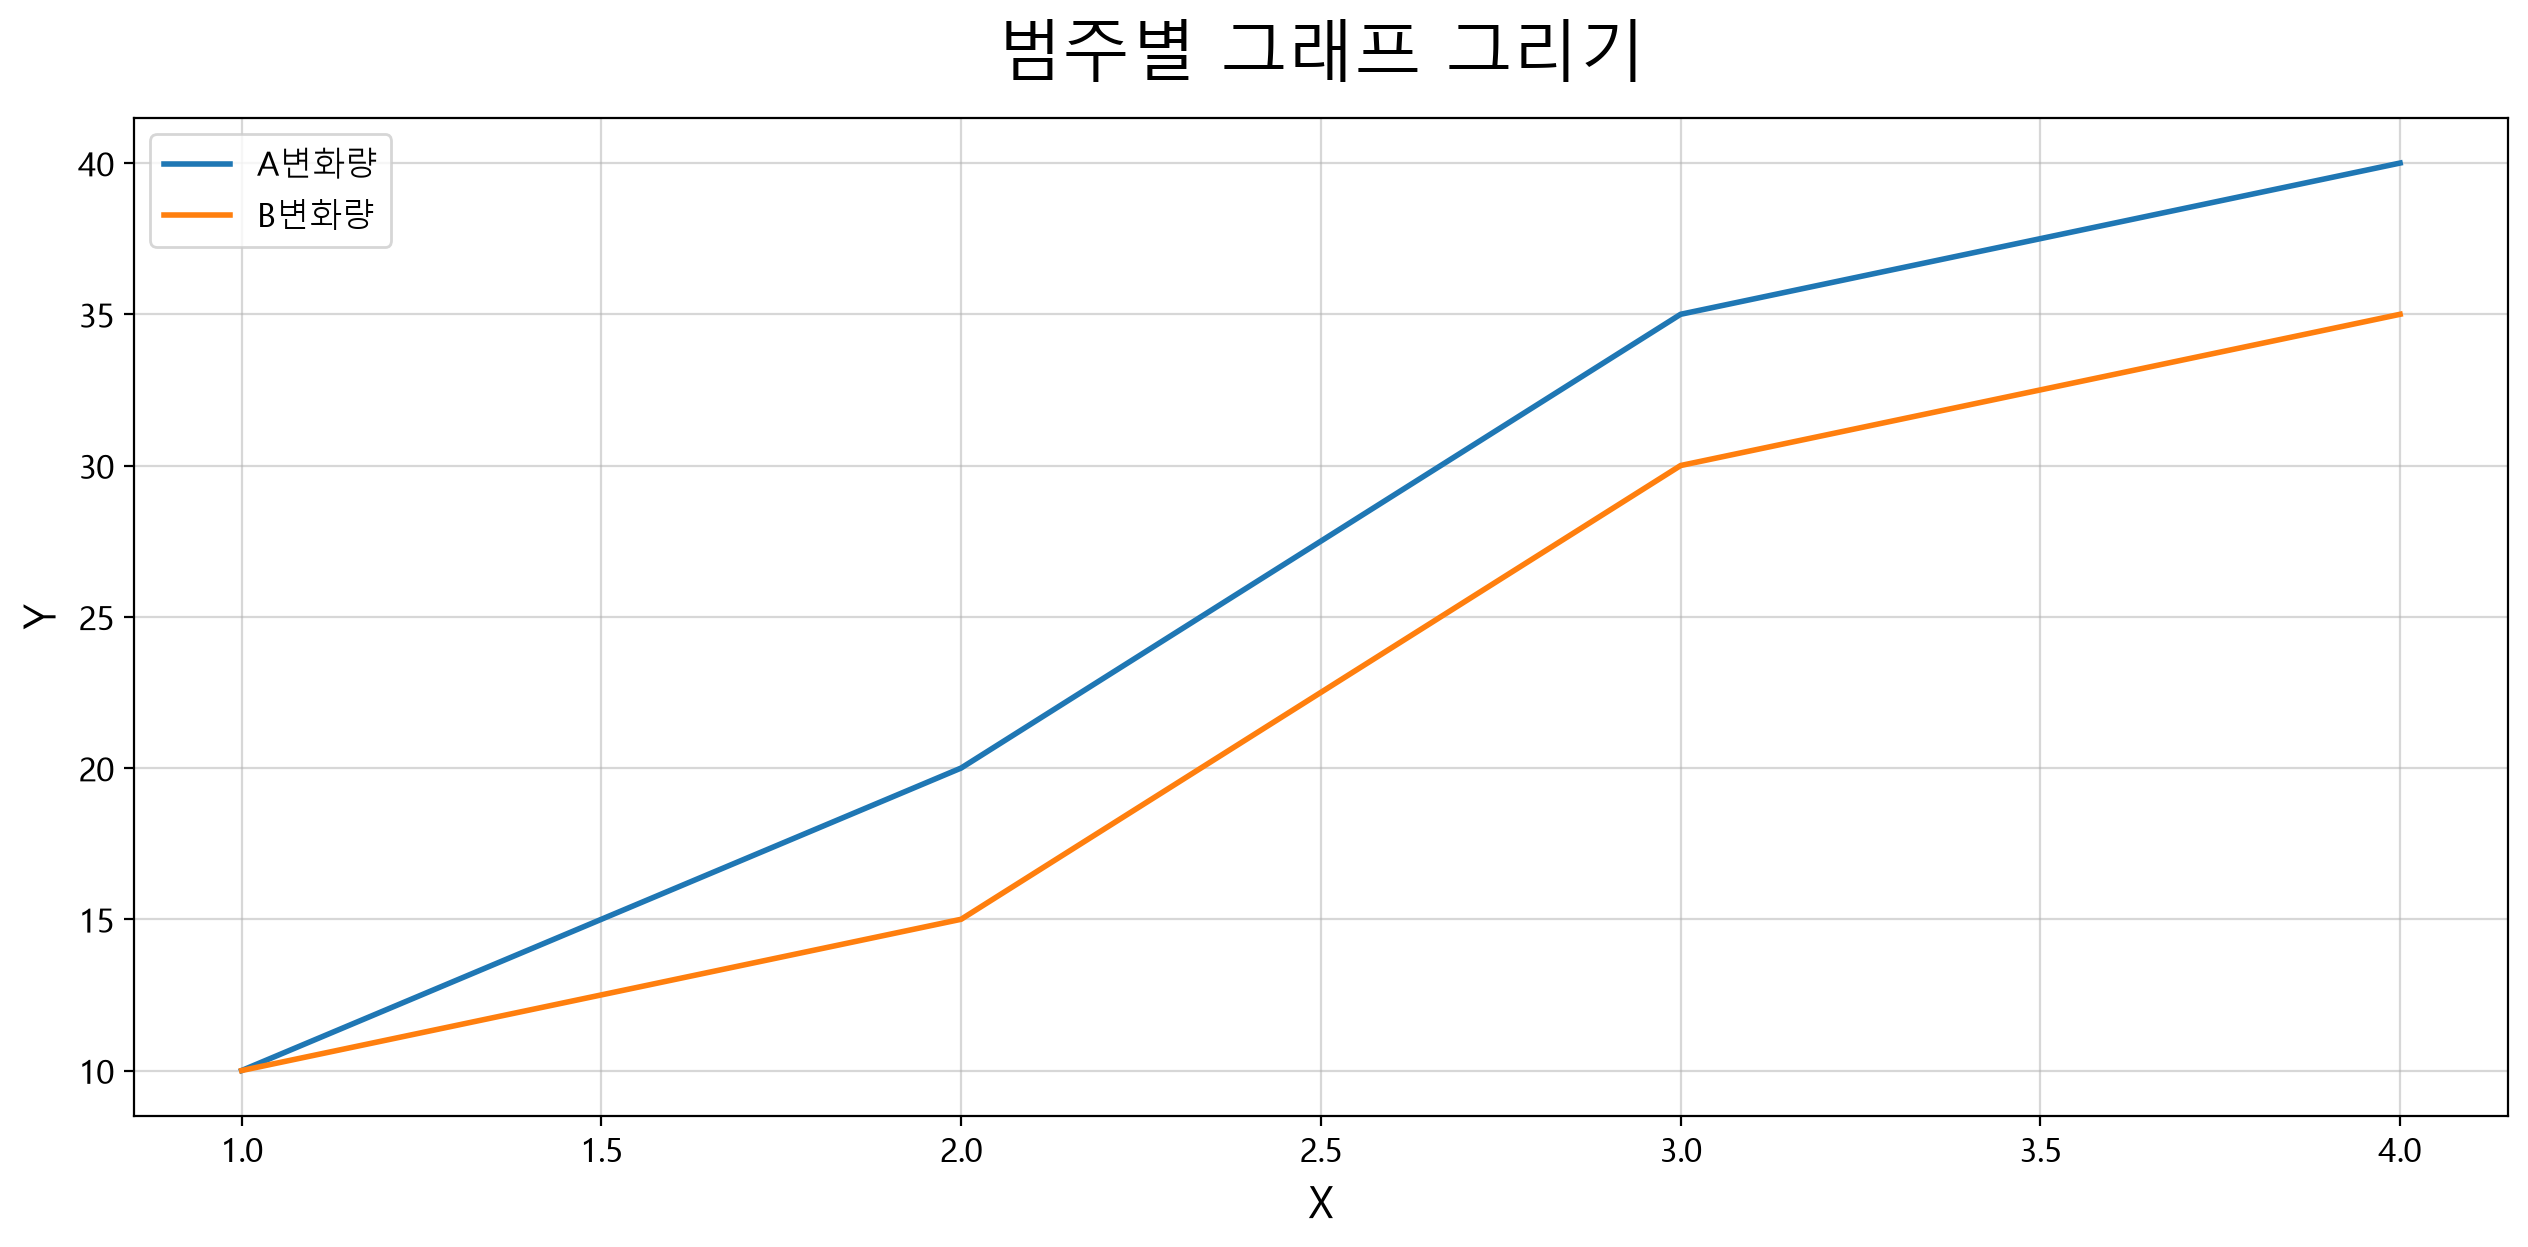

In [6]:
# 그래프 초기화 
fig, ax = my_plot.init(title="범주별 그래프 그리기", xlabel="X", ylabel="Y")

# 그래프 그리기 
sb.lineplot(x=[1,2,3,4], y=[10, 20, 35, 40], label="A변화량")
sb.lineplot(x=[1,2,3,4], y=[10, 15, 30, 35], label="B변화량")
ax.legend(loc='upper left') # 범주 위치 설정 (미설정시 자동으로 위치가 지정됨 )

# 출력 
my_plot.show()


## #05. 모듈화 기능 확인 

### 1. 선 그래프 모듈화 

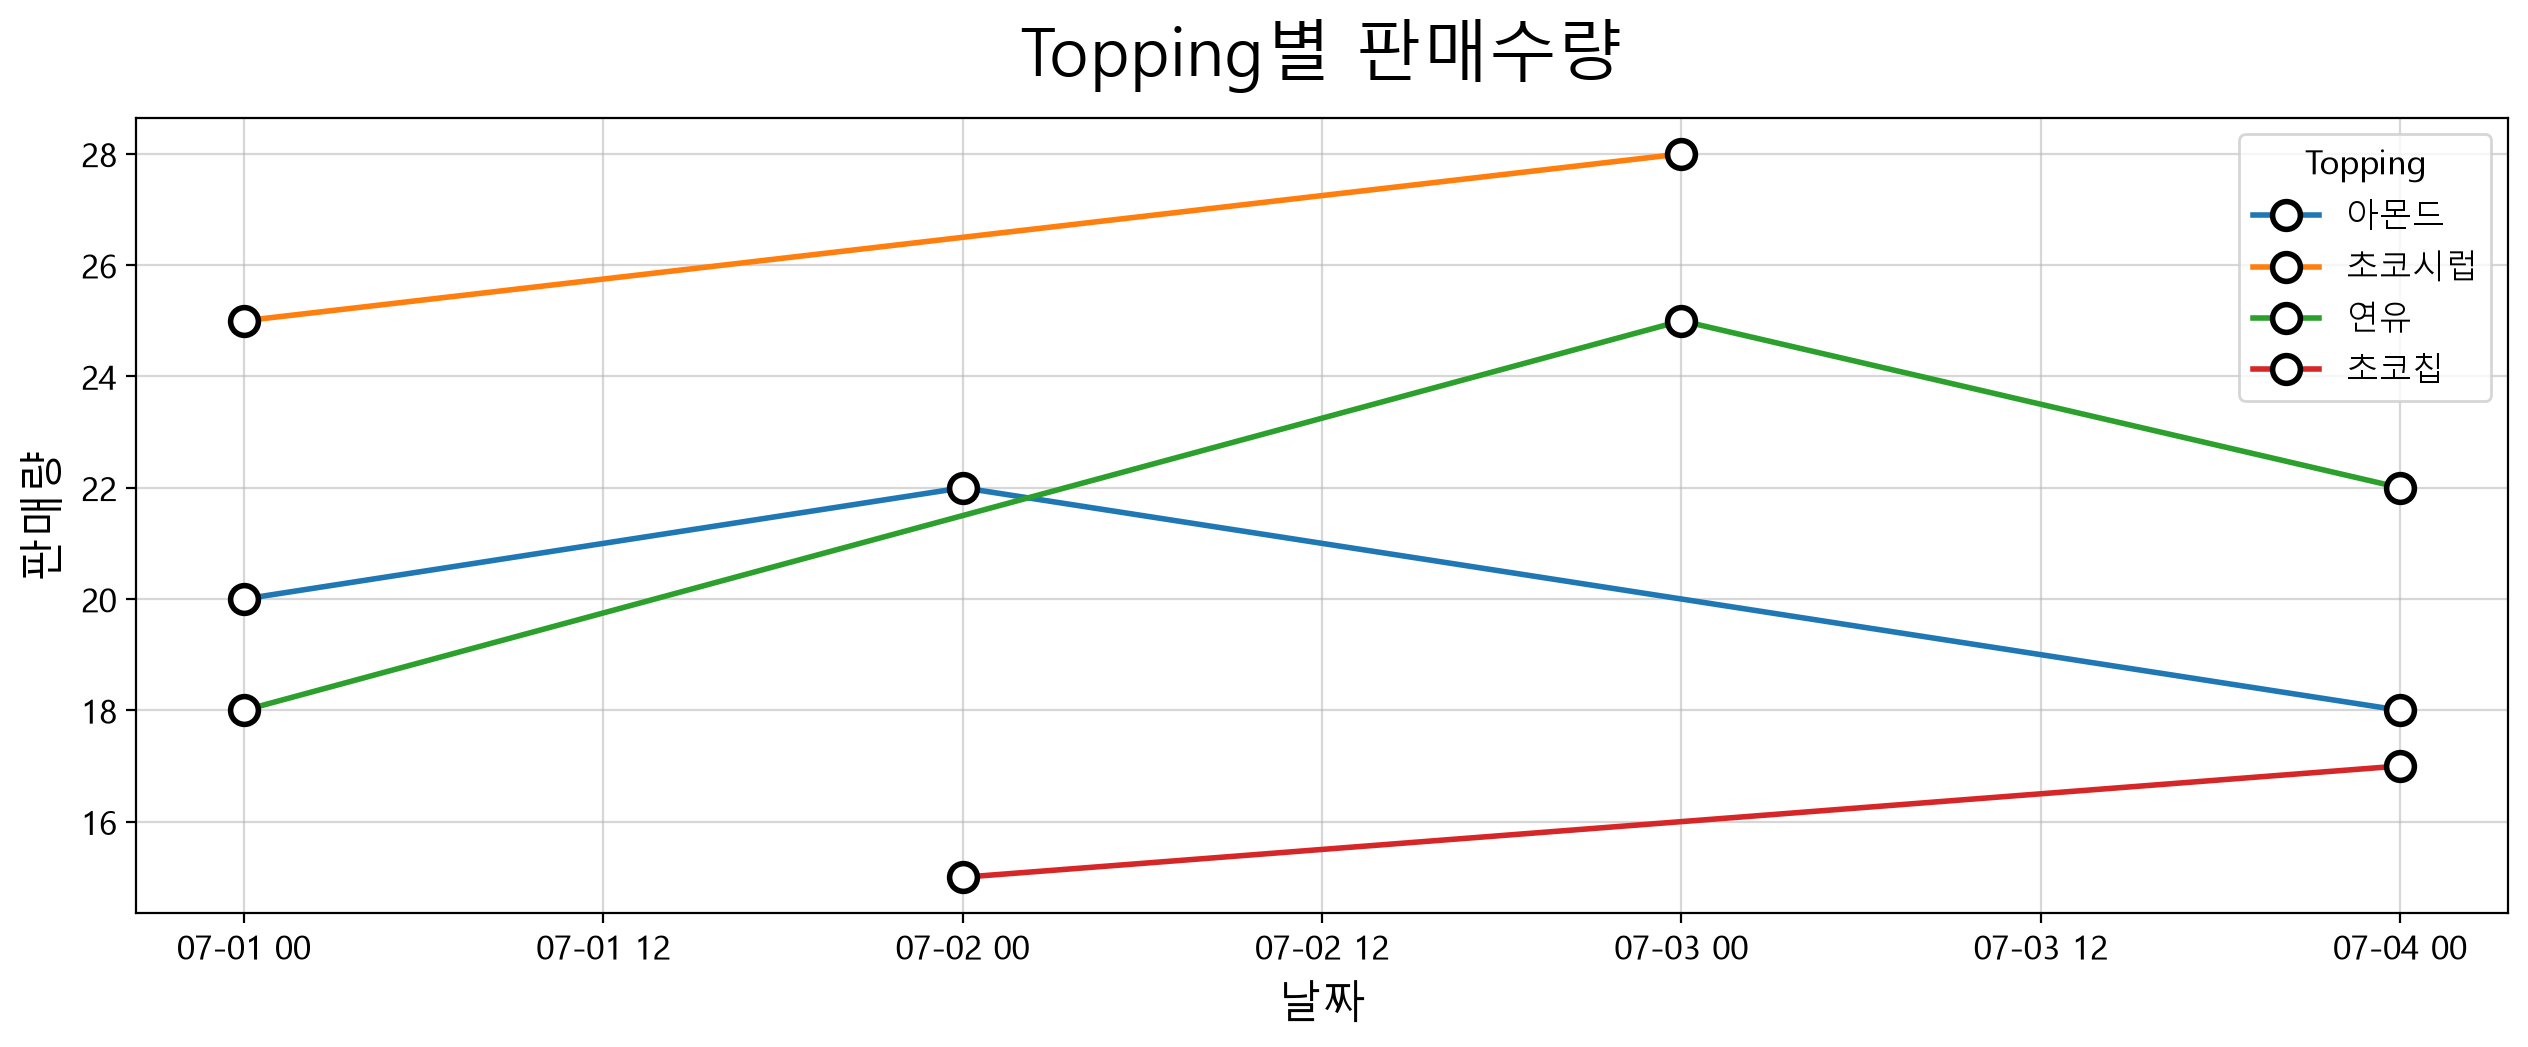

In [7]:
my_plot.lineplot(data=origin, x='Date', y="Quantity", hue="Topping", 
                 title="Topping별 판매수량", xlabel="날짜", ylabel="판매량",
                 marker="o", markersize=10, markeredgewidth=2, 
                 markeredgecolor="#000000", markerfacecolor="#ffffff")

## #01. 연습문제 

### Covid 19 확진자 수 변동 추이 시각화 

In [8]:
from jussam import load_data
from helpers import my_plot
from pandas import melt
import seaborn as sb

In [9]:
origin = load_data("covid19_active") 
origin 

📚 2022년 5월 1일부터 2023년 5월 31일까지 서울과 전국의 Covid19 일일 확진자 수를 기록한 데이터 (출처: 서울시)


,서울시 일일 확진,전국 일일 확진
기준일,,
2023-05-31,5987.000,24411.000
2023-05-30,3326.000,13529.000
2023-05-29,1393.000,6868.000
2023-05-28,1393.000,6868.000
2023-05-27,4078.000,17796.000
...,...,...
2022-05-05,6645.000,42296.000
2022-05-04,7436.000,49064.000
2022-05-03,8709.000,51131.000


In [10]:
df = origin.reset_index()
df.head()

,기준일,서울시 일일 확진,전국 일일 확진
0,2023-05-31,5987.000,24411.000
1,2023-05-30,3326.000,13529.000
2,2023-05-29,1393.000,6868.000
3,2023-05-28,1393.000,6868.000
4,2023-05-27,4078.000,17796.000


In [20]:
df2 = melt(df, id_vars='기준일', value_vars=['서울시 일일 확진', '전국 일일 확진'])
df2.head()

,기준일,variable,value
0,2023-05-31,서울시 일일 확진,5987.000
1,2023-05-30,서울시 일일 확진,3326.000
2,2023-05-29,서울시 일일 확진,1393.000
3,2023-05-28,서울시 일일 확진,1393.000
4,2023-05-27,서울시 일일 확진,4078.000


In [18]:
df2 = melt(df, id_vars='기준일', value_vars=['서울시 일일 확진', '전국 일일 확진'], 
           var_name='구분', value_name='확진자 수')
df2.head()

,기준일,구분,확진자 수
0,2023-05-31,서울시 일일 확진,5987.000
1,2023-05-30,서울시 일일 확진,3326.000
2,2023-05-29,서울시 일일 확진,1393.000
3,2023-05-28,서울시 일일 확진,1393.000
4,2023-05-27,서울시 일일 확진,4078.000


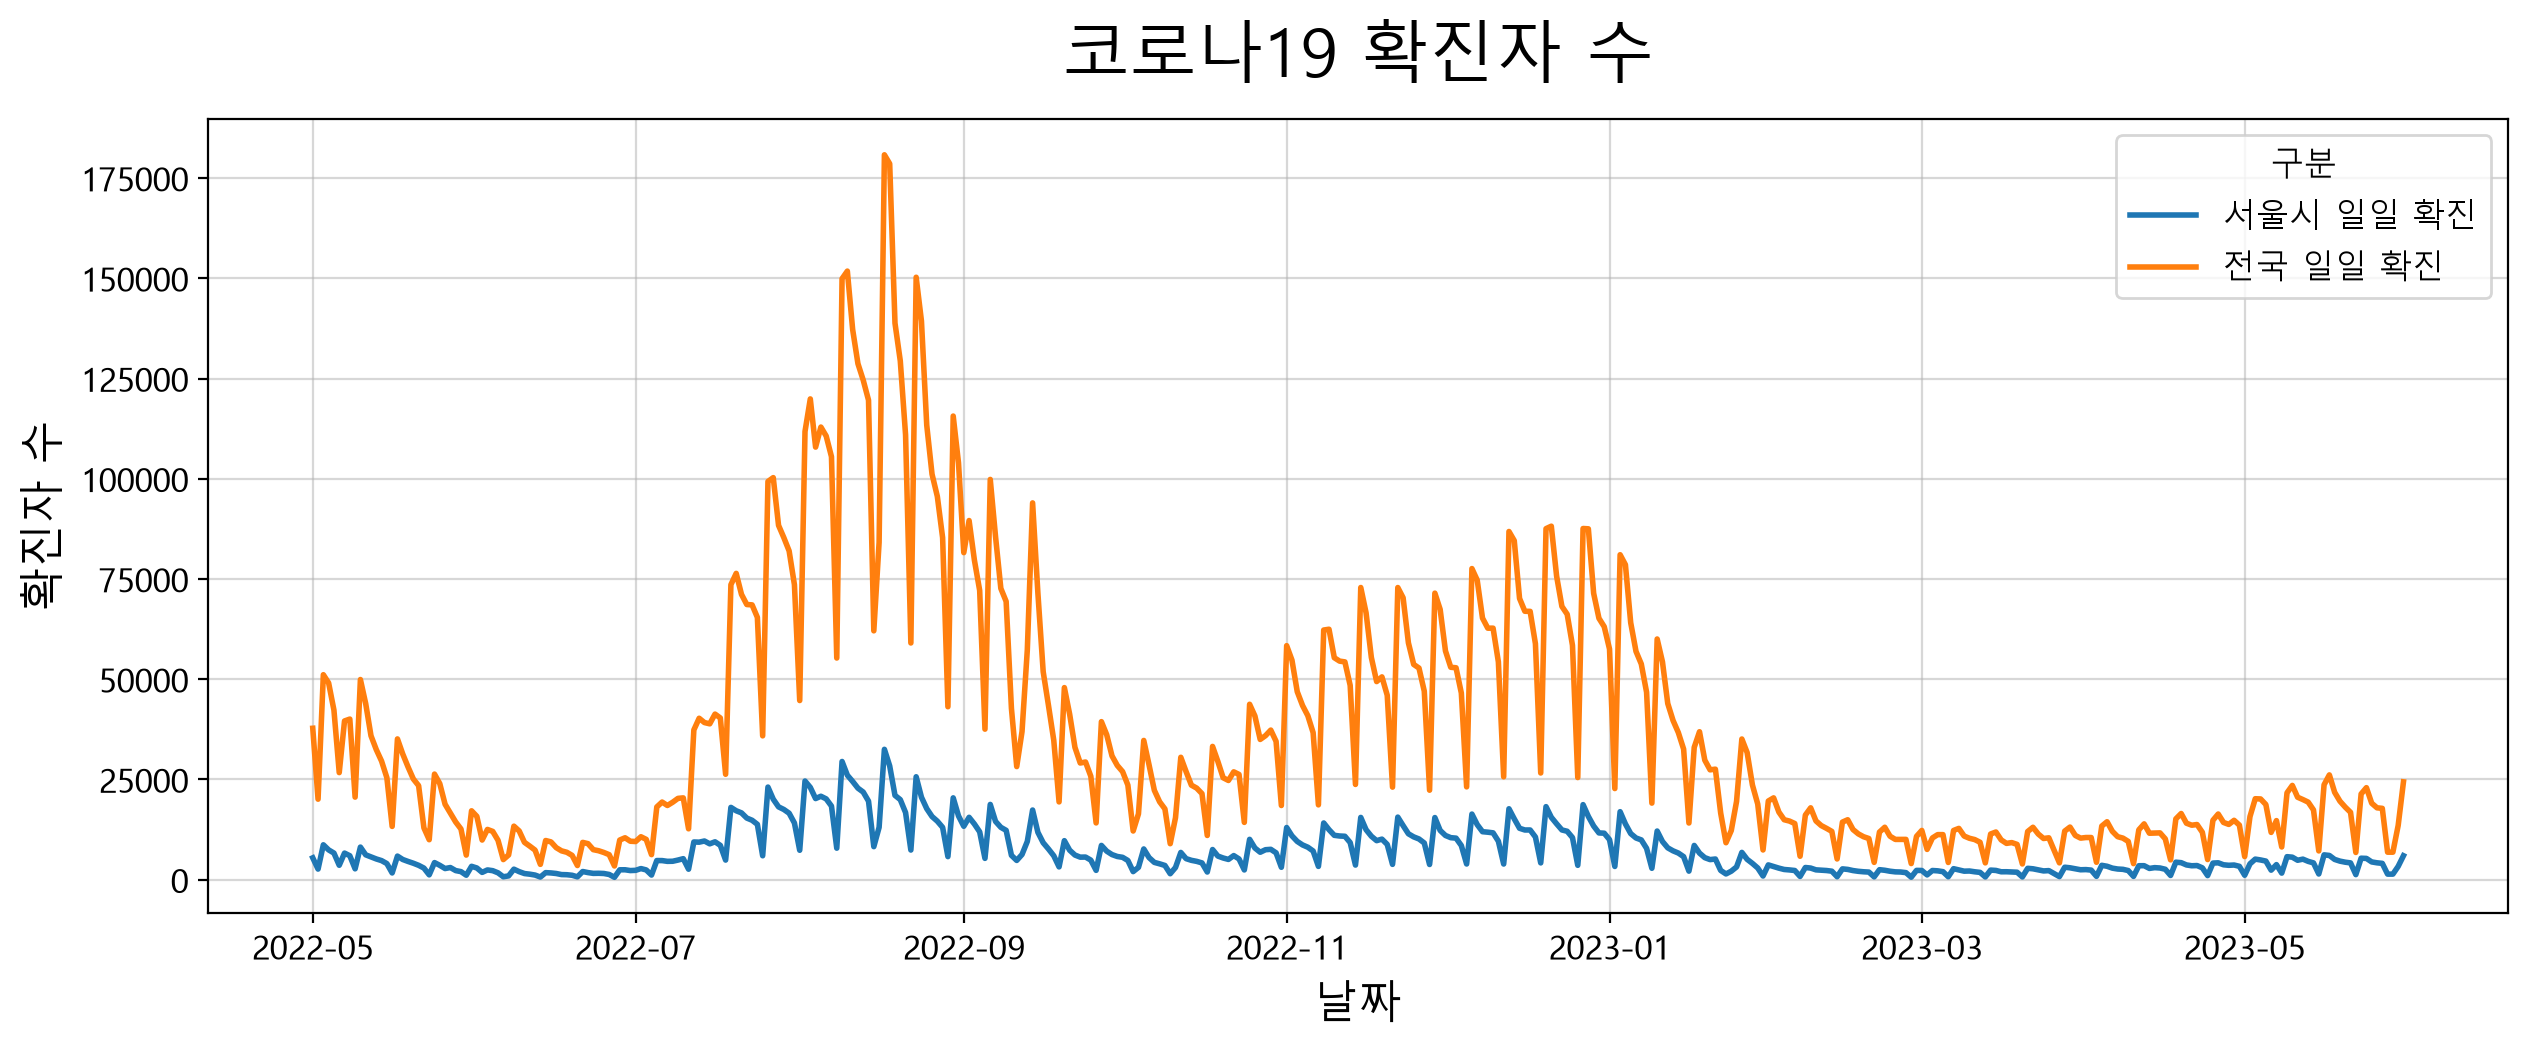

In [19]:
my_plot.lineplot(title="코로나19 확진자 수", 
                 xlabel="날짜", 
                 ylabel="확진자 수",
                 data=df2, 
                 x='기준일', 
                 y='확진자 수',
                 hue='구분')

<Axes: title={'center': 'covid19 전국 일일 확진자 수'}, xlabel='기준일', ylabel='전국 일일 확진'>

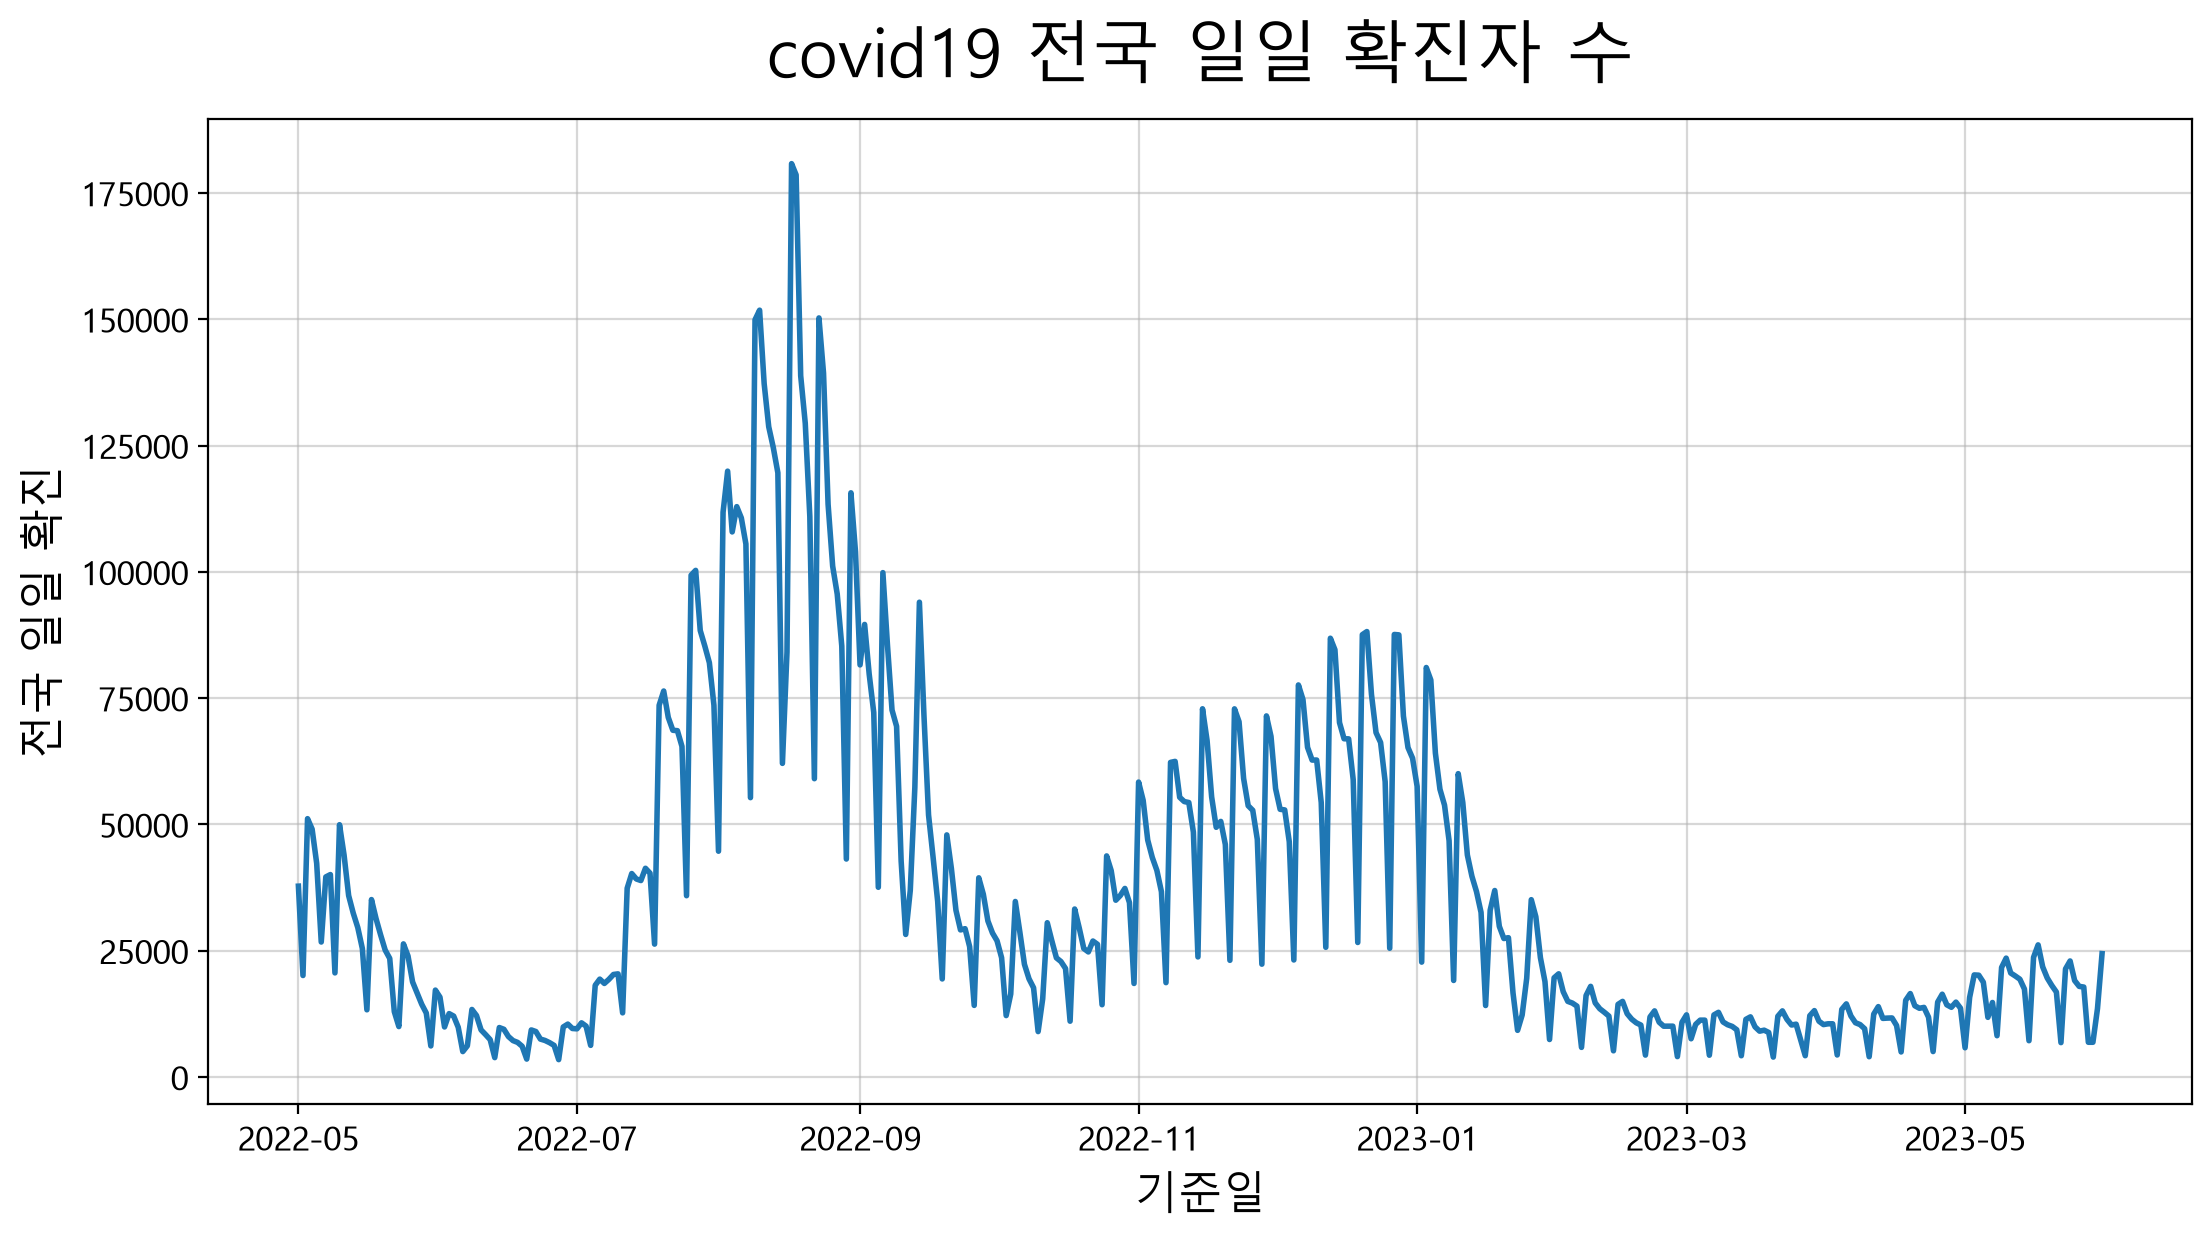

In [11]:
fig, ax = my_plot.init(title = "covid19 전국 일일 확진자 수", 
                       xlabel="기준일", ylabel="전국 일일 확진")

sb.lineplot(data=origin, x='기준일', y='전국 일일 확진')

In [12]:
origin.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 396 entries, 2023-05-31 to 2022-05-01
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   서울시 일일 확진  395 non-null    float64
 1   전국 일일 확진   395 non-null    float64
dtypes: float64(2)
memory usage: 9.3 KB


In [13]:
origin.describe()

,서울시 일일 확진,전국 일일 확진
count,395.000,395.000
mean,6893.742,36589.871
std,5932.760,33030.164
min,600.000,3429.000
25%,2463.500,12211.500
50%,4779.000,23583.000
75%,9833.500,53752.500
max,32523.000,180803.000


In [14]:
from pandas import DataFrame, pivot_table, melt

In [15]:
pivot1 = pivot_table(origin, 
            index=['서울시 일일 확진', '전국 일일 확진'], 
            )
pivot1

,
서울시 일일 확진,전국 일일 확진
600.000,3429.000
623.000,4026.000
663.000,3828.000
689.000,3930.000
690.000,4198.000
...,...
25679.000,150258.000
26068.000,151792.000
28375.000,178574.000


In [16]:
origin.melt()

,variable,value
0,서울시 일일 확진,5987.000
1,서울시 일일 확진,3326.000
2,서울시 일일 확진,1393.000
3,서울시 일일 확진,1393.000
4,서울시 일일 확진,4078.000
...,...,...
787,전국 일일 확진,42296.000
788,전국 일일 확진,49064.000
789,전국 일일 확진,51131.000
790,전국 일일 확진,20084.000


In [17]:
origin.groupby("variable")

KeyError: 'variable'

NameError: name 'x' is not defined

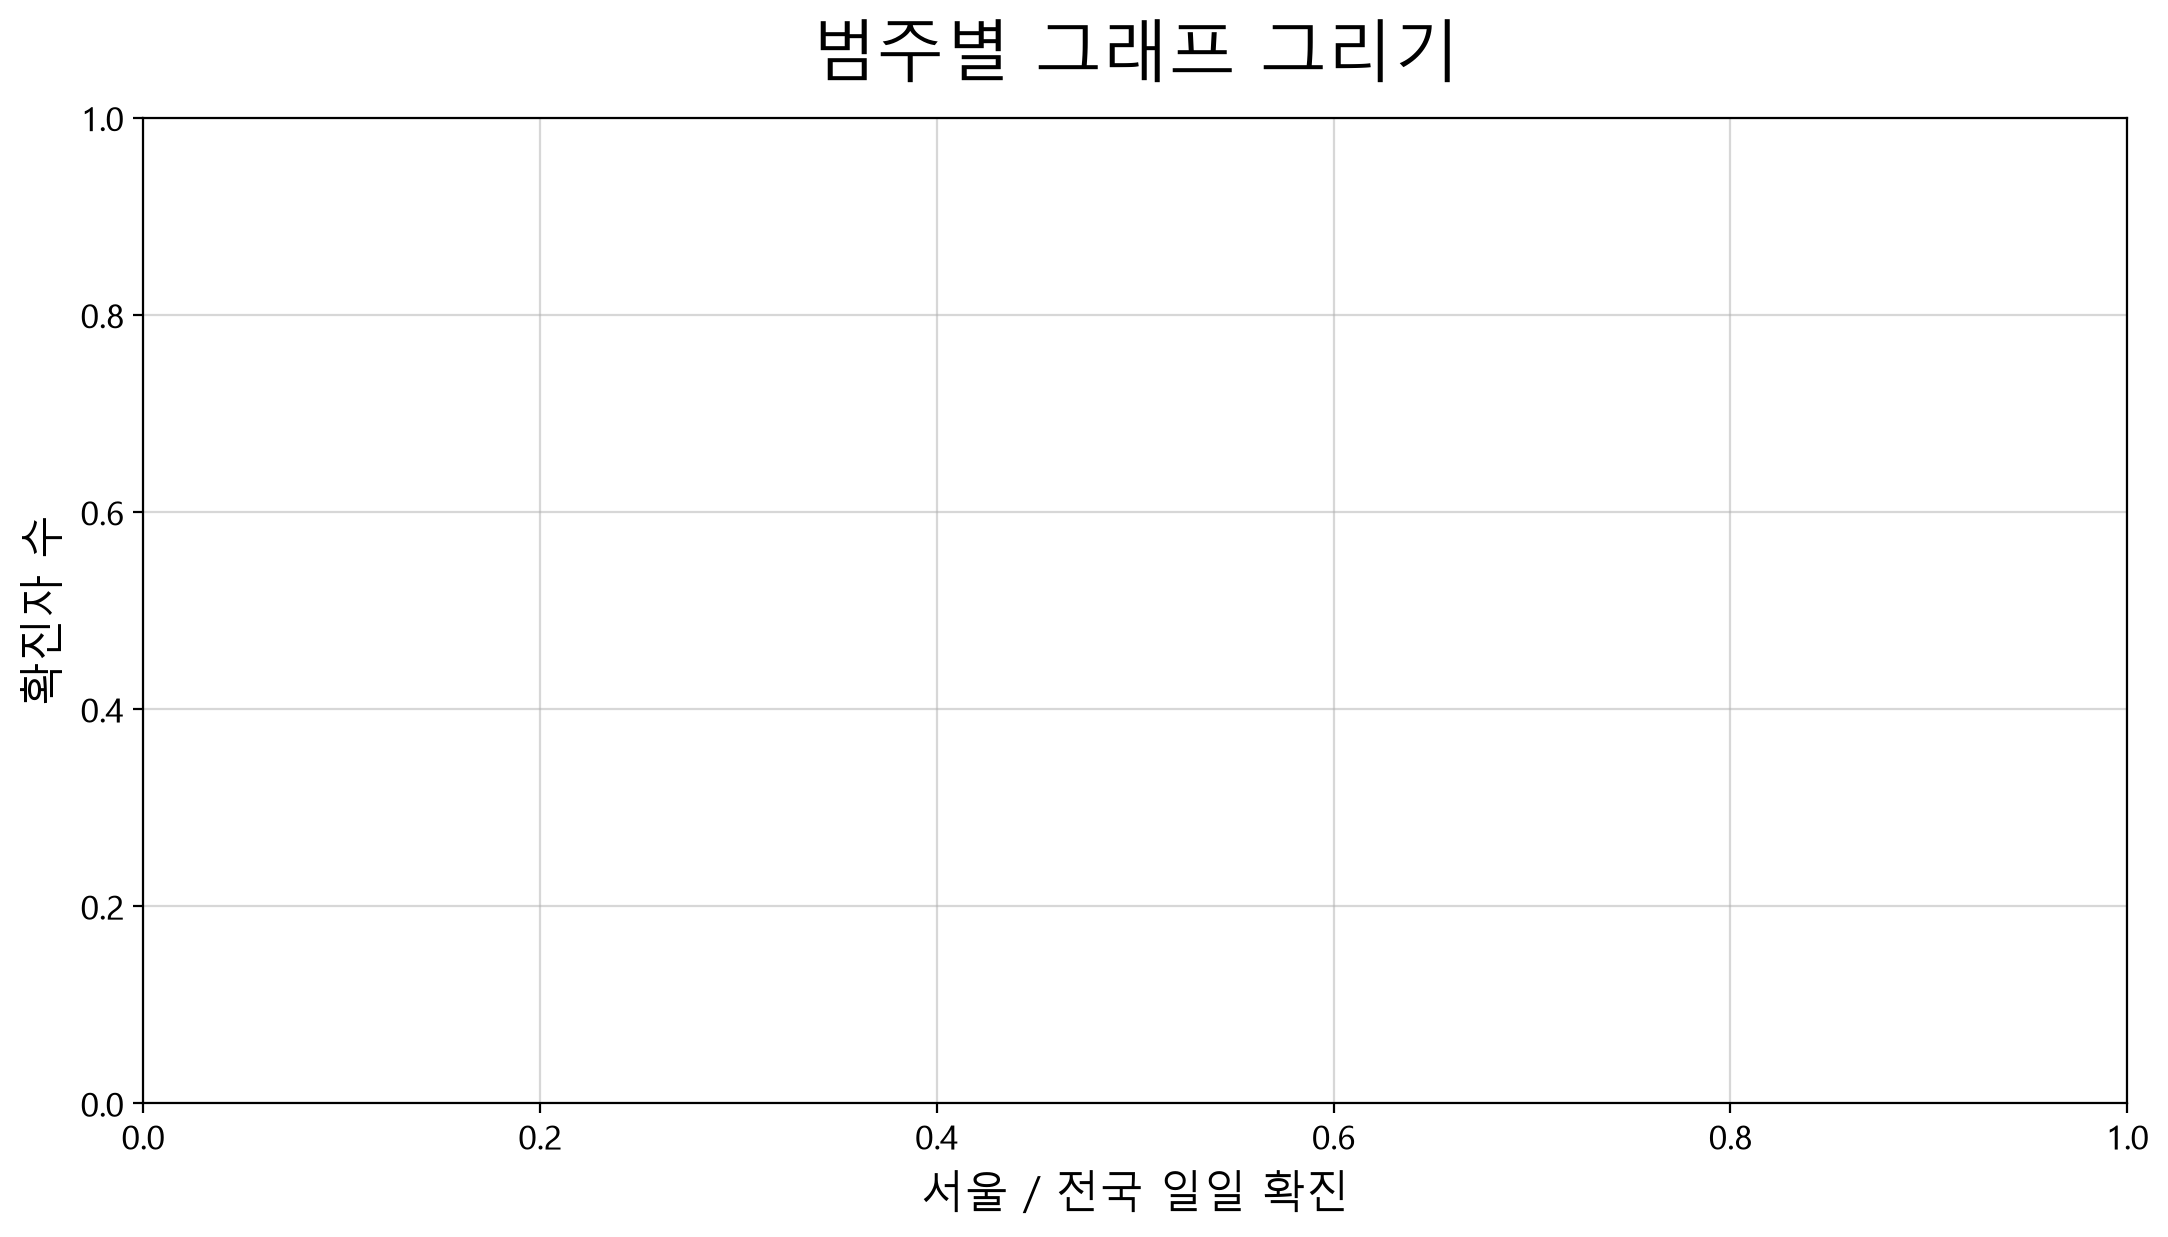

In [ ]:
fig, ax = my_plot.init(title="범주별 그래프 그리기", 
                       xlabel="서울 / 전국 일일 확진", 
                       ylabel="확진자 수")

sb.lineplot(x)